# 0_06 — qPISA against MEROPS: does the matrix represent real protease specificity?

## Scope

qPISA (Gudipati et al, *Mol Syst Biol* 2024,
[10.1038/s44320-024-00071-4](https://doi.org/10.1038/s44320-024-00071-4);
PRIDE PXD042089) measured the turnover of **every peptide in a tryptic HeLa
digest** under recombinant human DPP4, against a buffer control, by TMT
mass spectrometry. It is the only dataset in this analysis that supplies a
*quantitative, per-peptide* measurement of how strongly a named human
peptidase acts on tens of thousands of distinct sequences.

That makes it the one place where the central assumption of the whole
calibration can be tested directly rather than argued:

> the MEROPS specificity matrix, read through the masked window score,
> represents the substrate preference of a protease well enough to predict
> how fast a peptide is consumed.

The notebook answers three questions separately, and the answers are
independent of one another:

1. **Reproduction.** Does the MEROPS matrix recover the positional effects the
   paper measures — the $P_1$ ranking, and the strong *negative* $P_1'=$ Pro
   effect?
2. **Explained turnover.** How much of the measured turnover of 43 314 peptides
   does the masked window score account for?
3. **Benchmark.** How does it compare with the paper's own regression, on the
   same peptides, under an identical validation protocol?

Every peptide in the deposit is accounted for: each filter is stated, counted,
and justified, and nothing is selected by a threshold on the quantity being
studied.

## Execution contract

**Inputs:** `data/serum_proteolysis_calibration/raw/dpp4_qpisa/PMC11612144/44320_2024_71_MOESM2_ESM.xlsx`; `data/serum_proteolysis_calibration/raw/dpp4_qpisa/PMC11612144/44320_2024_71_MOESM3_ESM.xlsx`; `data/merops/34_homo_sapiens/codes.json`; `data/merops/34_homo_sapiens/matrices_counts.npy`; `data/reference/human_proteome/composition.json`.

**Outputs:** `results/0_06_windows.csv`; `results/0_06_funnel.csv`; `results/0_06_discrimination.csv`; `results/0_06_p1_effects.csv`; `results/0_06_p1prime_inhibition.csv`; `results/0_06_subsite_single.csv`; `results/0_06_subsite_cumulative.csv`; `results/0_06_subsite_leave_one_out.csv`; `results/0_06_benchmark.csv`; `results/0_06_profile_agreement.csv`; `results/0_06_profile_agreement_corrected.csv`; `results/0_06_intersection.csv`; `results/0_06_scored_peptides.csv`.

**Depends on:** none.

**Boundary:** A four-hour endpoint measures turnover extent, not a catalytic rate constant or serum half-life.

## Parameters

Every knob this notebook has is in the cell below. Shared policy that several
notebooks obey lives in `_analysis_common.py` and is imported rather than
repeated.

The one substantive filter is `KEEP_STATUS`. The deposit labels each peptide
`Tryptic+` or `Non-Tryptic+`. Tryptic peptides are the **input** of the assay —
they exist in both the treated and the control channel, so their fold change is
a measurement of consumption. Non-tryptic peptides are **products** of DPP4
cleavage: they have no baseline in the control, their own N terminus is a cut
site rather than a substrate window, and they accumulate rather than deplete.
Reading their first residues as a DPP4 substrate window would be a category
error, so they are held out as a control rather than analysed.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    compare_specificity_matrices,
    load_protease_panel,
    log_probability_matrix,
    masked_window_score,
    specificity_counts_from_windows,
)
from pep_compass.optimization.components.helpers.proteolysis.background import (
    load_amino_acid_background,
    normalize_background,
)

common.apply_style()

SOURCE_NAME = "qPISA"
SOURCE_ACCESSION = "PRIDE PXD042089 / PMC11612144"
QPISA_ROOT = common.SERUM_RAW / "dpp4_qpisa" / "PMC11612144"
PEPTIDE_LEVELS = QPISA_ROOT / "44320_2024_71_MOESM2_ESM.xlsx"      # Dataset EV1
PUBLISHED_MODEL = QPISA_ROOT / "44320_2024_71_MOESM3_ESM.xlsx"     # Dataset EV2

HUMAN_COMPOSITION = common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
DPP4_MEROPS_CODE = "S09.003"
# DPP4 is a dipeptidyl-peptidase: it releases the N-terminal dipeptide, so the
# scissile bond always follows residue 2 and the window is fixed by the geometry
# rather than inferred. P4 and P3 fall outside the peptide and are masked.
DPP4_BOND = 1
# The assay's input peptides. Products are held out as a control, see above.
KEEP_STATUS = "Tryptic+"
CONTROL_STATUS = "Non-Tryptic+"

# A peptide counts as strongly cleaved above this measured log2 depletion. Used
# only for reporting capture rates, never to select the analysis set.
STRONG_TURNOVER = 1.0
# Decile contrast used to report discrimination in measured units.
DISCRIMINATION_QUANTILE = 0.10
# Measured turnover above which a peptide is exported as countable cleavage
# evidence for `0_08`. It is used ONLY for that export: no analysis in this
# notebook thresholds the response variable.
EVIDENCE_TURNOVER_THRESHOLD = 1.0
# Folds of the shared cross-validation split. Every model in the benchmark is
# evaluated on exactly these folds.
N_FOLDS = 5
N_PERMUTATIONS = 200
SEED = common.SEED

## 1. The dataset: everything that is in it, and what is kept

### How the measurement was made

A commercial tryptic HeLa digest (Pierce 88329) was split in two. One half
received 0.5 µg recombinant hDPP4, the other buffer only; both were held at
21 °C, pH 7.4 for 4 h, heat-inactivated, TMT-labelled, pooled, and quantified
on an Orbitrap Fusion Lumos with SPS-MS3. The deposited levels are
$\log_2$-transformed and mean-centred, so the difference between the control
channel and the DPP4 channel **is** the $\log_2$ fold change. A positive value
means the peptide was consumed.

The assay has no time course: it is one 4 h endpoint. It therefore measures
*extent of turnover*, not a rate constant.

### The funnel

The deposited table is already the paper's filtered output — peptides with
ambiguous N-terminal flanks and those below a $\log_2$ intensity of $-4.7$ were
removed before deposition. The cell below accounts for every row that remains.

In [2]:
levels = pd.read_excel(PEPTIDE_LEVELS, sheet_name="Peptide_Levels_dpf-3_dpp4")
levels.columns = ["sequence", "status", "dpf3", "dpp4", "control_dpf3", "control_dpp4"]
levels["length"] = levels["sequence"].str.len()
## Levels are log2 and mean-centred, so the difference is the log2 fold change.
levels["turnover"] = levels["control_dpp4"] - levels["dpp4"]

## Every exclusion criterion, counted before any of them is applied
standard = levels["sequence"].str.fullmatch(r"[ACDEFGHIKLMNPQRSTVWY]+")
window_fits = levels["length"] >= 6
funnel = pd.DataFrame(
    {
        "step": [
            "peptides in the deposit (Dataset EV1)",
            f"  of which {KEEP_STATUS} (assay INPUT, substrates)",
            f"  of which {CONTROL_STATUS} (assay PRODUCTS, held out)",
            "excluded: non-standard residue in the sequence",
            "excluded: shorter than the P2..P4' window",
            "ANALYSIS SET",
        ],
        "peptides": [
            len(levels),
            int((levels["status"] == KEEP_STATUS).sum()),
            int((levels["status"] == CONTROL_STATUS).sum()),
            int((~standard).sum()),
            int((~window_fits).sum()),
            int(((levels["status"] == KEEP_STATUS) & standard & window_fits).sum()),
        ],
    }
)
funnel["percent_of_deposit"] = (100 * funnel["peptides"] / len(levels)).round(2)

substrates = levels[(levels["status"] == KEEP_STATUS) & standard & window_fits].reset_index(drop=True)
products = levels[levels["status"] == CONTROL_STATUS].reset_index(drop=True)

print(f"source: {SOURCE_NAME} ({SOURCE_ACCESSION})")
print(funnel.to_string(index=False))
print()
print("REMARK: neither exclusion criterion removes a single peptide. The whole")
print("funnel is the substrate/product split, which is a property of the assay.")
print()
print(f"measured turnover of the analysis set (log2 depletion), n = {len(substrates):,}")
print(substrates["turnover"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_string())
print()
print(f"held-out products (n = {len(products):,}) median turnover "
      f"{products['turnover'].median():+.3f} — negative, i.e. they accumulate, "
      f"which is what products must do")

source: qPISA (PRIDE PXD042089 / PMC11612144)
                                              step  peptides  percent_of_deposit
             peptides in the deposit (Dataset EV1)     53499              100.00
       of which Tryptic+ (assay INPUT, substrates)     43314               80.96
  of which Non-Tryptic+ (assay PRODUCTS, held out)     10185               19.04
    excluded: non-standard residue in the sequence         0                0.00
         excluded: shorter than the P2..P4' window         0                0.00
                                      ANALYSIS SET     43314               80.96

REMARK: neither exclusion criterion removes a single peptide. The whole
funnel is the substrate/product split, which is a property of the assay.

measured turnover of the analysis set (log2 depletion), n = 43,314
count    43314.000
mean         0.278
std          1.060
min         -6.041
5%          -0.310
25%         -0.134
50%         -0.064
75%          0.068
95%          2.963
ma

### Reading the figure

The left panel is the control that licenses the substrate/product split: input
peptides are consumed or unchanged, products accumulate. If the labels were
arbitrary the two distributions would sit on top of one another.

The right panel is the quantity every later section predicts. It is strongly
zero-inflated — most peptides in a HeLa digest are simply not DPP4 substrates —
with a long right tail of genuinely consumed peptides. **No threshold is applied
to it anywhere in this notebook**; the whole distribution is the response
variable.

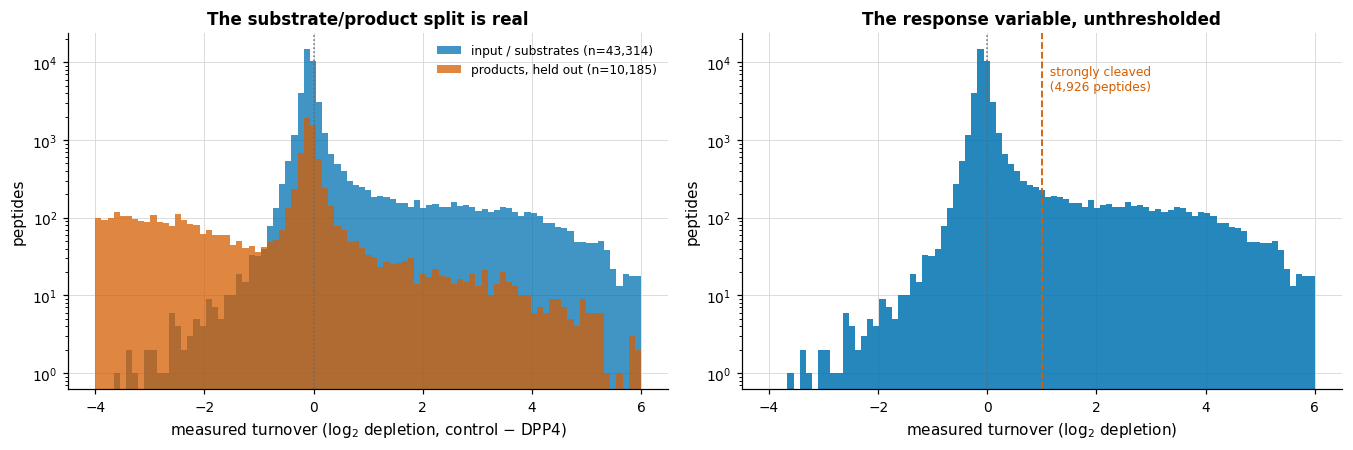

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

ax = axes[0]
bins = np.linspace(-4, 6, 90)
ax.hist(substrates["turnover"], bins=bins, color=common.CATEGORICAL_COLORS[0],
        alpha=0.75, label=f"input / substrates (n={len(substrates):,})")
ax.hist(products["turnover"], bins=bins, color=common.CATEGORICAL_COLORS[1],
        alpha=0.75, label=f"products, held out (n={len(products):,})")
ax.axvline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_yscale("log")
ax.set_xlabel("measured turnover (log$_2$ depletion, control − DPP4)")
ax.set_ylabel("peptides")
ax.set_title("The substrate/product split is real")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
ax.hist(substrates["turnover"], bins=bins, color=common.CATEGORICAL_COLORS[0], alpha=0.85)
ax.axvline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.axvline(STRONG_TURNOVER, color=common.CATEGORICAL_COLORS[1], linestyle="--", linewidth=1.2)
ax.text(STRONG_TURNOVER, ax.get_ylim()[1] * 0.6,
        f"  strongly cleaved\n  ({int((substrates['turnover'] > STRONG_TURNOVER).sum()):,} peptides)",
        fontsize=8, color=common.CATEGORICAL_COLORS[1], va="top")
ax.set_yscale("log")
ax.set_xlabel("measured turnover (log$_2$ depletion)")
ax.set_ylabel("peptides")
ax.set_title("The response variable, unthresholded")

fig.tight_layout()
plt.show()

**Provenance**

Gudipati et al. (2024), PMC11612144 / PRIDE PXD042089, supplies Dataset EV1 in `data/serum_proteolysis_calibration/raw/dpp4_qpisa/PMC11612144/44320_2024_71_MOESM2_ESM.xlsx`; EV2 is `44320_2024_71_MOESM3_ESM.xlsx`. The acquisition path is `assets/scripts/downloads/serum_proteolysis_calibration/download_pmc_supplements.py` and `download_pride_project.py`; the local paper is `report/articles/2024_10_28_Gudipati_Deep_quantification_of_substrate_turnover_defines_protease_subsite_cooperativity.pdf`. One row is one quantified peptide sequence in the deposited assay table, and the response is the control-minus-treated log2 intensity at four hours, not a rate. `results/0_06_funnel.csv` records 53,499 deposited rows: 43,314 `Tryptic+` input substrates retained, 10,185 `Non-Tryptic+` products held out, and zero further exclusions for nonstandard residues or short windows. Check the EV1 `Peptide_Levels_dpf-3_dpp4` sheet and code cell 4 for the exact label and filters. This one-enzyme, one-time-point experiment does not identify serum-scale kinetics.


## 2. The scores under comparison

Four predictors are computed for every one of the 43 314 substrate peptides.
They differ in how many parameters were fitted on *this* dataset, which is the
property that decides how their numbers may be read.

| score | what it is | parameters fitted here |
| --- | --- | --- |
| peptide length | trivial covariate, guards against a length artefact | none |
| MEROPS $P_1$ column | the single subsite the literature is clearest about | none |
| MEROPS masked window score | the score this whole analysis deploys, $S^M$ | none |
| qPISA published model (EV2) | the paper's fitted regression, read from the deposit | all of them |

The MEROPS scores have seen none of this data — the matrix is a tally of
literature-reported cleavages — so their performance is out-of-sample by
construction. The published model was fitted on exactly these peptides, so its
performance is an optimistic ceiling; §6 adds a cross-validated refit of the
same model form to give the leak-free version of that number.

The published model reduces to three additive terms,

$$s^{R} = \mathrm{P1}[P_1] \;+\; \mathrm{P2{:}P1}[P_2 \mid P_1] \;+\; \mathrm{P1'{:}P1}[P_1' \mid P_1],$$

because the authors folded the intercept and the marginal $P_2$ and $P_1'$ terms
into the interaction blocks.

In [4]:
panel = load_protease_panel(common.HUMAN_DATASET_ID, merops_root=common.MEROPS_ROOT,
                            kind="logprob", device="cpu")
merops_matrix = panel.matrices.numpy().astype(np.float64)[panel.codes.index(DPP4_MEROPS_CODE)]  # (8, 20)
background = np.log(normalize_background(
    load_amino_acid_background(HUMAN_COMPOSITION), len(MEROPS_AMINO_ACIDS)))  # (20,)
residue_index = {residue: index for index, residue in enumerate(MEROPS_AMINO_ACIDS)}

sequences = substrates["sequence"].to_numpy()

## MEROPS: the deployed window score, and the P1 column of the same matrix alone
window_score = np.empty(len(sequences))
p1_score = np.empty(len(sequences))
for position, sequence in enumerate(sequences):
    value, _ = masked_window_score(sequence, DPP4_BOND, merops_matrix)
    window_score[position] = value
    code = residue_index[sequence[1]]
    p1_score[position] = merops_matrix[3, code] - background[code]   # subsite 3 == P1

## The paper's published model, read from Dataset EV2
published_parameters = pd.read_excel(PUBLISHED_MODEL, sheet_name="dpp4_modelParams").set_index(
    "Amino acid (single letter code)")
p1_term = published_parameters["P1"].to_dict()
p2_interaction = {(p1, column.split(":")[1]): value
                  for p1, row in published_parameters.iterrows()
                  for column, value in row.items() if column.startswith("P2:")}
prime_interaction = {(p1, column.split(":")[1]): value
                     for p1, row in published_parameters.iterrows()
                     for column, value in row.items() if column.startswith("P1':")}
published_score = np.array([
    p1_term[s[1]]
    + np.nan_to_num(p2_interaction.get((s[1], s[0])), nan=0.0)
    + np.nan_to_num(prime_interaction.get((s[1], s[2])), nan=0.0)
    for s in sequences
])

scored = pd.DataFrame({
    "sequence": sequences,
    "length": substrates["length"].to_numpy(),
    "turnover": substrates["turnover"].to_numpy(),
    "merops_window": window_score,
    "merops_p1": p1_score,
    "published_model": published_score,
})
turnover = scored["turnover"].to_numpy()

print(f"scored peptides: {len(scored):,} — the whole analysis set, none dropped")
print()
print(scored[["turnover", "merops_window", "merops_p1", "published_model"]]
      .describe().round(3).to_string())
print()
## The published model is reconstructed, not assumed: it must reproduce the
## engineering result of Fig 4A, where the GLP-1 variants were designed.
print("reconstruction check — GLP-1 (7-37) variants of the paper's Fig 4A:")
for tripeptide, expected in (("HAE", "wild type, fully processed in <=30 min"),
                             ("DAE", "P2 His->Asp, strongly reduced"),
                             ("HAP", "P1' Glu->Pro, abolished"),
                             ("DAP", "both, abolished"),
                             ("YAD", "GRF-amide, the least stable substrate of Keane et al")):
    value = (p1_term[tripeptide[1]]
             + p2_interaction[(tripeptide[1], tripeptide[0])]
             + prime_interaction[(tripeptide[1], tripeptide[2])])
    print(f"  {tripeptide}  score {value:+.3f}   ({expected})")

scored peptides: 43,314 — the whole analysis set, none dropped

        turnover  merops_window  merops_p1  published_model
count  43314.000      43314.000  43314.000        43314.000
mean       0.278         -1.974     -0.979            0.374
std        1.060          2.109      0.957            0.865
min       -6.041         -7.010     -2.024           -1.388
25%       -0.134         -3.455     -1.687            0.016
50%       -0.064         -2.105     -1.193            0.030
75%        0.068         -0.670     -0.509            0.130
max        8.589          7.099      2.192            4.289

reconstruction check — GLP-1 (7-37) variants of the paper's Fig 4A:
  HAE  score +2.169   (wild type, fully processed in <=30 min)
  DAE  score +0.984   (P2 His->Asp, strongly reduced)
  HAP  score -0.202   (P1' Glu->Pro, abolished)
  DAP  score -1.388   (both, abolished)
  YAD  score +3.133   (GRF-amide, the least stable substrate of Keane et al)


## 3. Does the MEROPS score discriminate at all?

Before asking how *much* the score explains, it has to be established that it
explains anything, and against what.

Two references are used. The **permutation null** shuffles the score against the
measurements, which destroys any relation while keeping both marginal
distributions — it says what a correlation of this size would look like by
chance. The **decile contrast** is the same question in units a reader can act
on: take the peptides the score ranks in its top tenth, take those in its bottom
tenth, and report the difference in measured turnover.

In [5]:
generator = np.random.default_rng(SEED)

discrimination = []
for label, column in (("MEROPS masked window score", "merops_window"),
                      ("MEROPS P1 column only", "merops_p1"),
                      ("qPISA published model (EV2)", "published_model")):
    score = scored[column].to_numpy()
    top = turnover[score >= np.quantile(score, 1.0 - DISCRIMINATION_QUANTILE)]
    bottom = turnover[score <= np.quantile(score, DISCRIMINATION_QUANTILE)]
    pooled = np.sqrt((top.var(ddof=1) + bottom.var(ddof=1)) / 2.0)
    strong = turnover > STRONG_TURNOVER
    captured = strong[score >= np.quantile(score, 1.0 - DISCRIMINATION_QUANTILE)].sum()
    discrimination.append({
        "score": label,
        "top_decile_median_turnover": float(np.median(top)),
        "bottom_decile_median_turnover": float(np.median(bottom)),
        "separation_log2": float(top.mean() - bottom.mean()),
        "cohens_d": float((top.mean() - bottom.mean()) / pooled),
        "percent_of_strongly_cleaved_in_top_decile": float(100 * captured / strong.sum()),
    })
discrimination = pd.DataFrame(discrimination)

## The null: shuffling the score destroys the relation but keeps both margins
observed_rho = float(spearmanr(scored["merops_window"], turnover).statistic)
null_rho = np.array([
    float(spearmanr(generator.permutation(scored["merops_window"].to_numpy()), turnover).statistic)
    for _ in range(N_PERMUTATIONS)
])

print(discrimination.round(3).to_string(index=False))
print()
print(f"permutation null for the window score ({N_PERMUTATIONS} shuffles):")
print(f"  observed Spearman  {observed_rho:+.4f}")
print(f"  null mean {null_rho.mean():+.4f}, sd {null_rho.std():.4f}, "
      f"95th percentile of |null| {np.quantile(np.abs(null_rho), 0.95):+.4f}")
print(f"  observed is {abs(observed_rho) / null_rho.std():.0f} null standard deviations out")
print()
print("So the window score carries real information, and 10% of the peptides it")
print(f"ranks highest hold {discrimination.loc[0, 'percent_of_strongly_cleaved_in_top_decile']:.1f}% "
      "of all strongly cleaved peptides against 10% by chance.")
print("Whether that is a lot is the question of sections 4 to 6.")

                      score  top_decile_median_turnover  bottom_decile_median_turnover  separation_log2  cohens_d  percent_of_strongly_cleaved_in_top_decile
 MEROPS masked window score                       0.185                         -0.076            1.297     0.984                                     36.521
      MEROPS P1 column only                       2.265                         -0.086            2.313     1.806                                     73.670
qPISA published model (EV2)                       2.806                         -0.096            2.934     2.733                                     76.959

permutation null for the window score (200 shuffles):
  observed Spearman  +0.1811
  null mean +0.0002, sd 0.0048, 95th percentile of |null| +0.0104
  observed is 38 null standard deviations out

So the window score carries real information, and 10% of the peptides it
ranks highest hold 36.5% of all strongly cleaved peptides against 10% by chance.
Whether that is a lot

### Reading the figure

Each panel bins the peptides by *decile of the score* and reports the measured
turnover inside each bin. A score that orders peptides by how fast they are
consumed produces a monotone staircase; a score that does not produces a flat
line. The dotted line is the median turnover of the whole analysis set.

The comparison across panels is the informative part, and the axis is shared so
the three are directly comparable.

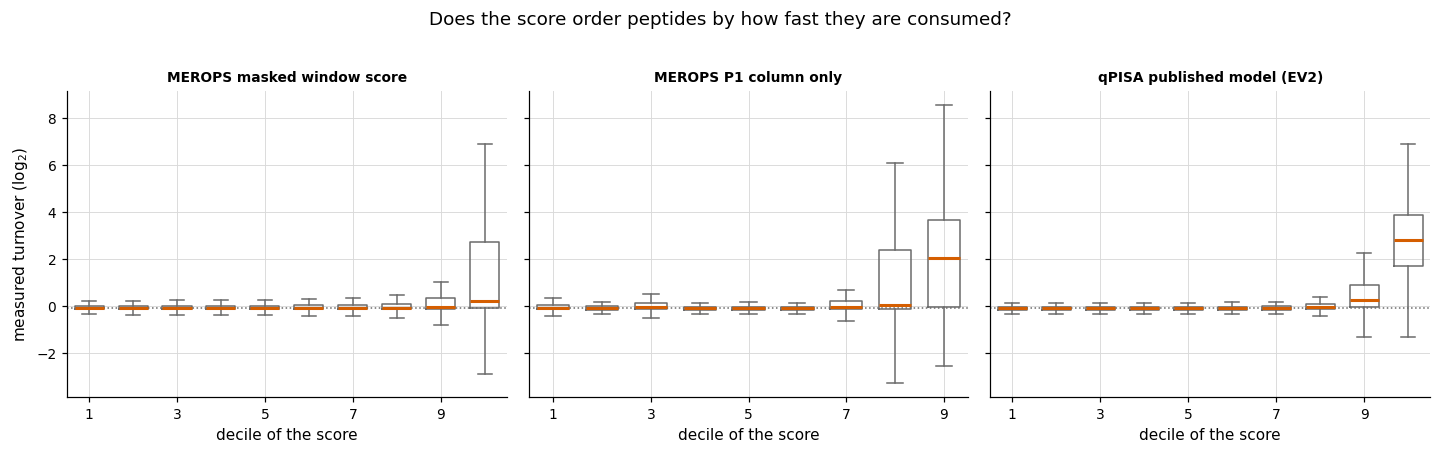

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0), sharey=True)
overall_median = float(np.median(turnover))

for ax, (label, column) in zip(axes, (("MEROPS masked window score", "merops_window"),
                                      ("MEROPS P1 column only", "merops_p1"),
                                      ("qPISA published model (EV2)", "published_model"))):
    score = scored[column].to_numpy()
    decile = pd.qcut(score, 10, labels=False, duplicates="drop")
    grouped = [turnover[decile == d] for d in sorted(pd.unique(decile[~pd.isna(decile)]))]
    parts = ax.boxplot(grouped, positions=range(len(grouped)), widths=0.66, showfliers=False,
                       medianprops={"color": common.CATEGORICAL_COLORS[1], "linewidth": 2.0},
                       boxprops={"color": common.NEUTRAL},
                       whiskerprops={"color": common.NEUTRAL},
                       capprops={"color": common.NEUTRAL})
    ax.axhline(overall_median, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
    ax.set_xticks(range(0, len(grouped), 2))
    ax.set_xticklabels([f"{d + 1}" for d in range(0, len(grouped), 2)])
    ax.set_xlabel("decile of the score")
    ax.set_title(label, fontsize=9)

axes[0].set_ylabel("measured turnover (log$_2$)")
fig.suptitle("Does the score order peptides by how fast they are consumed?", y=1.02)
fig.tight_layout()
plt.show()

## 4. Reproduction: does MEROPS recover the paper's positional effects?

The paper establishes two effects that between them carry most of DPP4's
specificity. Both are reproduced here from the raw measurements, and the MEROPS
matrix is then asked the same question.

### 4.1 The $P_1$ ranking

The paper reports Pro and Ala as the two strongly cleavage-promoting residues at
$P_1$, with Ala close behind Pro — which contradicts the impression the MEROPS
tally gives, where Pro appears in 21 of 29 recorded cleavages and Ala in 4.

Three columns are compared below: the **measured** mean turnover of every peptide
carrying that residue at $P_1$, the paper's **fitted** $P_1$ term, and the
**MEROPS** log-odds of that residue at $P_1$.

In [7]:
p1_residues = np.array([s[1] for s in sequences])
merops_counts = np.load(common.MEROPS_ROOT / "34_homo_sapiens" / "matrices_counts.npy")
import json as _json
merops_metadata = _json.loads((common.MEROPS_ROOT / "34_homo_sapiens" / "codes.json").read_text())
merops_row = next(entry["row"] for entry in merops_metadata["peptidases"]
                  if entry["code"] == DPP4_MEROPS_CODE)
dpp4_counts = merops_counts[merops_row]   # (8, 20)

p1_table = pd.DataFrame([
    {
        "residue": residue,
        "peptides_measured": int((p1_residues == residue).sum()),
        "measured_mean_turnover": float(turnover[p1_residues == residue].mean()),
        "paper_P1_term": float(p1_term[residue]),
        "merops_log_odds": float(merops_matrix[3, residue_index[residue]] - background[residue_index[residue]]),
        "merops_raw_count": int(dpp4_counts[3, residue_index[residue]]),
    }
    for residue in MEROPS_AMINO_ACIDS if (p1_residues == residue).sum() > 0
]).sort_values("measured_mean_turnover", ascending=False).reset_index(drop=True)

print(p1_table.round(3).to_string(index=False))
print()
for label, column in (("measured   ", "measured_mean_turnover"),
                      ("paper model", "paper_P1_term"),
                      ("MEROPS     ", "merops_log_odds")):
    order = p1_table.sort_values(column, ascending=False)["residue"].head(5).to_list()
    print(f"  top 5 at P1, {label}: {' > '.join(order)}")
print()
print(f"rank correlation, MEROPS log-odds vs measured: "
      f"{spearmanr(p1_table['merops_log_odds'], p1_table['measured_mean_turnover']).statistic:+.3f}")
print(f"rank correlation, paper term  vs measured:     "
      f"{spearmanr(p1_table['paper_P1_term'], p1_table['measured_mean_turnover']).statistic:+.3f}")
print()
pro = p1_table.set_index("residue").loc["P"]
ala = p1_table.set_index("residue").loc["A"]
print(f"Ala as a fraction of Pro:  measured {ala['measured_mean_turnover'] / pro['measured_mean_turnover']:.0%}"
      f"   paper {ala['paper_P1_term'] / pro['paper_P1_term']:.0%}"
      f"   MEROPS {ala['merops_log_odds'] / pro['merops_log_odds']:.0%}")

residue  peptides_measured  measured_mean_turnover  paper_P1_term  merops_log_odds  merops_raw_count
      P               1560                   3.018          3.072            2.192                21
      A               2965                   2.375          2.633            0.524                 4
      S               2794                   0.649          0.883           -1.848                 0
      T               2230                   0.269          0.498           -1.408                 0
      G               2898                   0.180          0.337           -0.509                 1
      N               1644                  -0.035          0.095           -1.002                 0
      V               3459                  -0.044          0.084           -1.510                 0
      M                800                  -0.076          0.022           -0.482                 0
      W                424                  -0.079          0.032            0.082         

### Reading the figure

The left panel puts the three accounts of $P_1$ side by side on their own scales,
for the residues that matter. The right panel is the diagnosis: MEROPS log-odds
against measured effect, with each residue labelled and coloured by **how many
cleavages MEROPS actually recorded there**. Residues MEROPS never observed still
receive a log-odds, and because that value is driven by the *background*
frequency of the residue rather than by evidence, rare residues are pushed
upward without a single observation behind them.

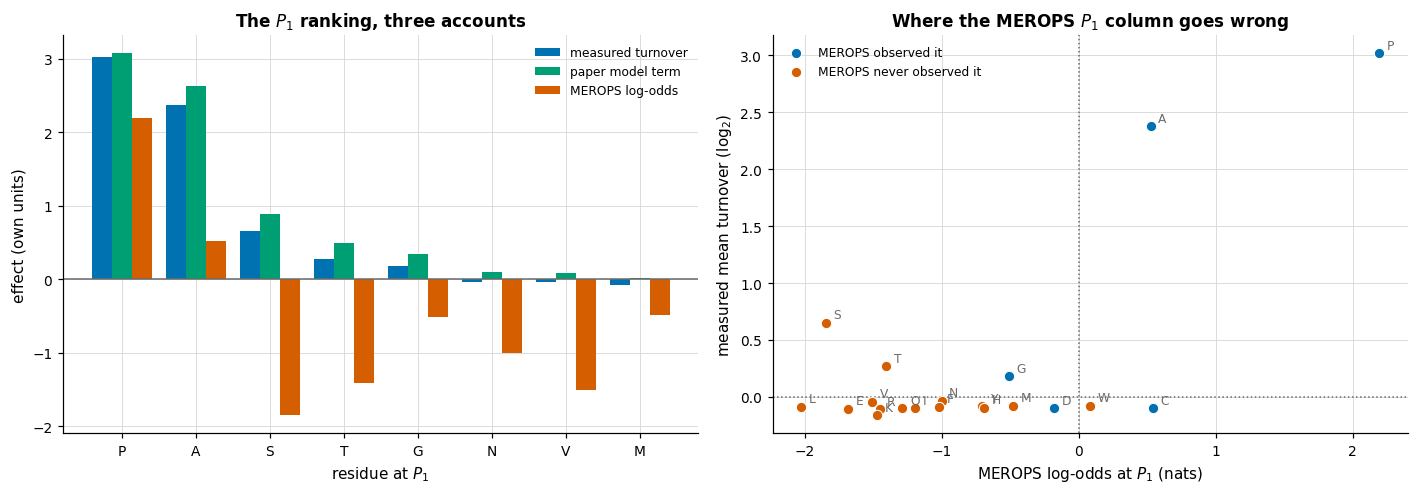

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

ax = axes[0]
shown = p1_table.head(8)
positions = np.arange(len(shown))
width = 0.27
for offset, (column, label, colour) in enumerate((
        ("measured_mean_turnover", "measured turnover", common.CATEGORICAL_COLORS[0]),
        ("paper_P1_term", "paper model term", common.CATEGORICAL_COLORS[2]),
        ("merops_log_odds", "MEROPS log-odds", common.CATEGORICAL_COLORS[1]))):
    ax.bar(positions + (offset - 1) * width, shown[column], width=width,
           color=colour, label=label)
ax.axhline(0.0, color=common.NEUTRAL, linewidth=1.0)
ax.set_xticks(positions)
ax.set_xticklabels(shown["residue"])
ax.set_xlabel("residue at $P_1$")
ax.set_ylabel("effect (own units)")
ax.set_title("The $P_1$ ranking, three accounts")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
observed_mask = p1_table["merops_raw_count"] > 0
for mask, colour, label in ((observed_mask, common.CATEGORICAL_COLORS[0], "MEROPS observed it"),
                            (~observed_mask, common.CATEGORICAL_COLORS[1], "MEROPS never observed it")):
    subset = p1_table[mask]
    ax.scatter(subset["merops_log_odds"], subset["measured_mean_turnover"],
               s=46, color=colour, edgecolor="white", linewidth=0.7, label=label, zorder=3)
for _, row in p1_table.iterrows():
    ax.annotate(row["residue"], (row["merops_log_odds"], row["measured_mean_turnover"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8, color=common.NEUTRAL)
ax.axhline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.axvline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("MEROPS log-odds at $P_1$ (nats)")
ax.set_ylabel("measured mean turnover (log$_2$)")
ax.set_title("Where the MEROPS $P_1$ column goes wrong")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

**Provenance**

The DPP4 comparator comes from MEROPS *Substrate_search* 2023, `data/merops/34_homo_sapiens/codes.json`, `matrices_counts.npy`, and `matrices_logprob.npy`; code cells 8 and 14 select its DPP4 code and compare its residue profile with the qPISA EV1 measurements. One count in the MEROPS matrix is one literature-reported cleavage, while qPISA supplies one turnover endpoint per input peptide. `results/0_06_p1_effects.csv` holds the grouped P1 comparison; the corresponding qPISA unit remains log2 intensity difference. The named PDF and EV1 sheet above support manual inspection of the P1 effect. Agreement in residue ranking cannot calibrate absolute catalytic efficiency.


### 4.2 $P_1' =$ Pro, the paper's largest negative predictor

This is the harder test, and it is the one that probes a structural property of
the MEROPS representation rather than the amount of evidence behind it.

The paper finds that proline at $P_1'$ is the single largest *negative* term in
the model: it cancels the positive contribution of Pro or Ala at $P_1$ outright,
because a second backbone kink is incompatible with the binding mode. A peptide
reading Pro-Pro is essentially not cleaved.

A MEROPS matrix is a tally of cleavages that **were** observed. It has no channel
for "this residue prevents cleavage": a residue that blocks the reaction is
simply absent, and absence is also what an unstudied residue looks like. The
test below asks whether the representation can express the effect at all.

In [9]:
prime_residues = np.array([s[2] for s in sequences])
inhibition = []
for base in ("P", "A", "S"):
    selected = p1_residues == base
    with_proline = selected & (prime_residues == "P")
    without_proline = selected & (prime_residues != "P")
    if with_proline.sum() < 20:
        continue
    inhibition.append({
        "P1_residue": base,
        "peptides_with_P1prime_Pro": int(with_proline.sum()),
        "peptides_with_other": int(without_proline.sum()),
        "turnover_with_Pro": float(turnover[with_proline].mean()),
        "turnover_with_other": float(turnover[without_proline].mean()),
        "measured_effect": float(turnover[with_proline].mean() - turnover[without_proline].mean()),
        "paper_model_term": float(prime_interaction[(base, "P")]),
    })
inhibition = pd.DataFrame(inhibition)

proline_code = residue_index["P"]
merops_prime = merops_matrix[4] - background            # (20,)
merops_prime_pro = float(merops_prime[proline_code])

print(inhibition.round(3).to_string(index=False))
print()
print("What MEROPS has at P1':")
print(f"  log-odds for Pro                {merops_prime_pro:+.3f} nats")
print(f"  raw cleavages recorded for Pro  {int(dpp4_counts[4, proline_code])}")
print(f"  residues observed at all        {int((dpp4_counts[4] > 0).sum())}/20 "
      f"(from {int(dpp4_counts[4].sum())} cleavages)")
print(f"  full dynamic range at P1'       [{merops_prime.min():+.3f}, {merops_prime.max():+.3f}] "
      f"= {merops_prime.max() - merops_prime.min():.3f} nats wide")
print()
print("The decisive arithmetic — can the additive score express the effect?")
pro_at_p1 = float(merops_matrix[3, proline_code] - background[proline_code])
print(f"  MEROPS P1=Pro contributes       {pro_at_p1:+.3f} nats")
print(f"  MEROPS P1'=Pro contributes      {merops_prime_pro:+.3f} nats")
print(f"  sum for a Pro-Pro peptide       {pro_at_p1 + merops_prime_pro:+.3f} nats  -> still favourable")
print(f"  measured turnover of Pro-Pro    {turnover[(p1_residues == 'P') & (prime_residues == 'P')].mean():+.3f} "
      f"log2, against {turnover[(p1_residues == 'P') & (prime_residues != 'P')].mean():+.3f} for Pro-other")
print()
print("REMARK: Pro is at the floor of the MEROPS P1' column, but only because it")
print("has zero recorded cleavages there — it is tied with every other unobserved")
print("residue. The value is absence of evidence, not evidence of inhibition, and")
print("the column is too narrow to overturn the P1 term in any case.")

P1_residue  peptides_with_P1prime_Pro  peptides_with_other  turnover_with_Pro  turnover_with_other  measured_effect  paper_model_term
         P                        124                 1436             -0.082                3.286           -3.368            -3.058
         A                        172                 2793             -0.099                2.528           -2.626            -2.612
         S                        156                 2638             -0.074                0.692           -0.766            -0.771

What MEROPS has at P1':
  log-odds for Pro                -1.333 nats
  raw cleavages recorded for Pro  0
  residues observed at all        9/20 (from 20 cleavages)
  full dynamic range at P1'       [-1.371, +1.479] = 2.849 nats wide

The decisive arithmetic — can the additive score express the effect?
  MEROPS P1=Pro contributes       +2.192 nats
  MEROPS P1'=Pro contributes      -1.333 nats
  sum for a Pro-Pro peptide       +0.860 nats  -> still favourable


### Reading the figure

The left panel is the measured effect: the turnover distribution of peptides
carrying Pro at $P_1$, split by whether $P_1'$ is also Pro. The two distributions
barely overlap — this is not a subtle modulation, it is an on/off switch.

The right panel is what each representation has to say about it, on a common
axis of "effect relative to the same position's own spread". The MEROPS bar is
short not because MEROPS judges the effect small, but because the column has
almost no dynamic range to spend.

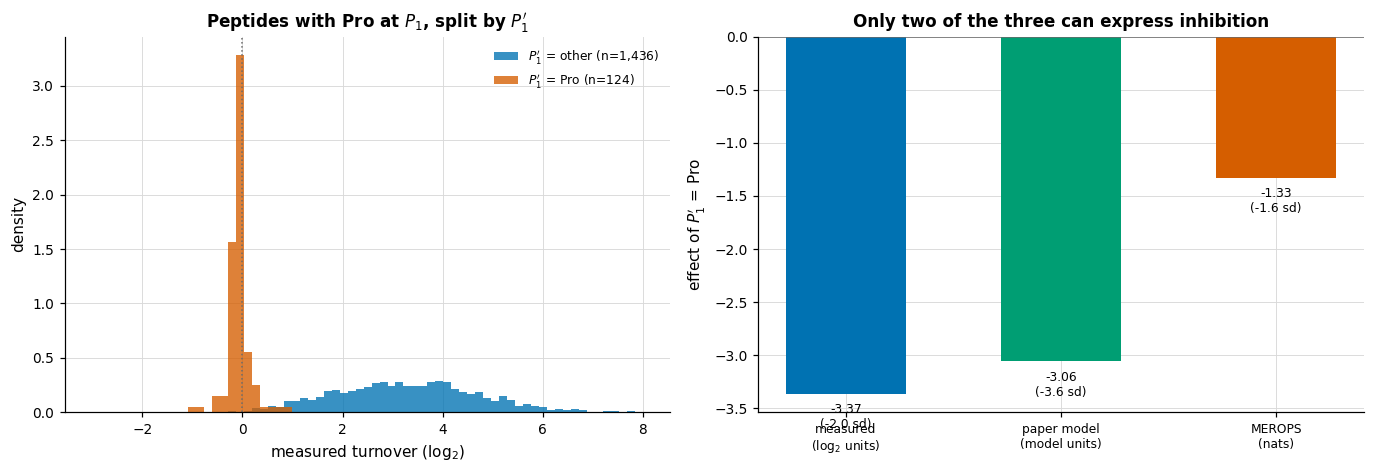

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
selected = p1_residues == "P"
bins = np.linspace(-3, 8, 70)
ax.hist(turnover[selected & (prime_residues != "P")], bins=bins, density=True,
        color=common.CATEGORICAL_COLORS[0], alpha=0.78,
        label=f"$P_1'$ = other (n={int((selected & (prime_residues != 'P')).sum()):,})")
ax.hist(turnover[selected & (prime_residues == "P")], bins=bins, density=True,
        color=common.CATEGORICAL_COLORS[1], alpha=0.78,
        label=f"$P_1'$ = Pro (n={int((selected & (prime_residues == 'P')).sum()):,})")
ax.axvline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("measured turnover (log$_2$)")
ax.set_ylabel("density")
ax.set_title("Peptides with Pro at $P_1$, split by $P_1'$")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
labels = ["measured\n(log$_2$ units)", "paper model\n(model units)", "MEROPS\n(nats)"]
values = [float(inhibition.loc[inhibition["P1_residue"] == "P", "measured_effect"].iloc[0]),
          float(inhibition.loc[inhibition["P1_residue"] == "P", "paper_model_term"].iloc[0]),
          merops_prime_pro]
spreads = [float(turnover[selected].std()),
           float(np.nanstd(list(published_parameters["P1':P"].astype(float)))),
           float(merops_prime.std())]
colours = [common.CATEGORICAL_COLORS[0], common.CATEGORICAL_COLORS[2], common.CATEGORICAL_COLORS[1]]
ax.bar(range(3), values, color=colours, width=0.56)
for position, (value, spread) in enumerate(zip(values, spreads)):
    ax.annotate(f"{value:+.2f}\n({value / spread:+.1f} sd)", (position, value),
                ha="center", va="top" if value < 0 else "bottom",
                textcoords="offset points", xytext=(0, -6 if value < 0 else 6), fontsize=8)
ax.axhline(0.0, color=common.NEUTRAL, linewidth=1.0)
ax.set_xticks(range(3))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("effect of $P_1'$ = Pro")
ax.set_title("Only two of the three can express inhibition")

fig.tight_layout()
plt.show()

## 5. How much measured turnover does the masked window score explain?

This is the measurement the calibration has never had. The window score is an
additive sum over subsites, so it can be taken apart the same way: each subsite
contributes one term, and the contribution of any subset can be evaluated
against the same 43 314 measurements.

Two things are reported. The **cumulative** view adds subsites in the order the
paper ranks them. The **leave-one-out** view removes one subsite at a time from
the deployed six-subsite score, so a positive change means that subsite is
actively making the prediction worse.

In [11]:
## Map each window position of the DPP4 geometry onto its MEROPS subsite index
LAYOUT = (("P2", 0, 2), ("P1", 1, 3), ("P1'", 2, 4),
          ("P2'", 3, 5), ("P3'", 4, 6), ("P4'", 5, 7))
subsite_contribution = {}
for name, offset, subsite in LAYOUT:
    codes = np.array([residue_index[s[offset]] for s in sequences])
    subsite_contribution[name] = merops_matrix[subsite, codes] - background[codes]


def explained(names: tuple[str, ...]) -> dict[str, float]:
    """Spearman and R^2 of a subset of subsites against measured turnover.

    :param names: Subsite names to sum.
    :return: Rank correlation and the R^2 of a linear calibration of the sum.
    """

    score = sum(subsite_contribution[name] for name in names)
    design = np.vstack([np.ones(len(score)), score]).T
    coefficients, *_ = np.linalg.lstsq(design, turnover, rcond=None)
    residual = turnover - design @ coefficients
    return {
        "spearman": float(spearmanr(score, turnover).statistic),
        "r2": float(1.0 - residual @ residual / ((turnover - turnover.mean()) @ (turnover - turnover.mean()))),
    }


single = pd.DataFrame([{"subsites": name, **explained((name,))} for name, _, _ in LAYOUT])
cumulative = pd.DataFrame([
    {"subsites": " + ".join(subset), "n_subsites": len(subset), **explained(subset)}
    for subset in (("P1",), ("P1", "P1'"), ("P2", "P1", "P1'"),
                   ("P2", "P1", "P1'", "P2'"), ("P2", "P1", "P1'", "P2'", "P3'"),
                   ("P2", "P1", "P1'", "P2'", "P3'", "P4'"))
])
full_names = tuple(name for name, _, _ in LAYOUT)
full_r2 = explained(full_names)["r2"]
leave_one_out = pd.DataFrame([
    {"dropped": name,
     "r2_without": explained(tuple(k for k in full_names if k != name))["r2"],
     "change": explained(tuple(k for k in full_names if k != name))["r2"] - full_r2}
    for name in full_names
]).sort_values("change", ascending=False)

print("Each subsite on its own:")
print(single.round(4).to_string(index=False))
print()
print("Adding subsites one at a time:")
print(cumulative.round(4).to_string(index=False))
print()
print("Removing one subsite from the deployed six-subsite score:")
print(leave_one_out.round(4).to_string(index=False))
print()
print(f"The deployed window score reaches R2 = {full_r2:.4f}.")
print(f"Its own P1 column alone reaches R2 = {single.set_index('subsites').loc['P1', 'r2']:.4f}.")
print("Every subsite added after P1 costs accuracy.")

Each subsite on its own:
subsites  spearman     r2
      P2    0.0136 0.0003
      P1    0.2065 0.3116
     P1'    0.0379 0.0031
     P2'    0.0432 0.0019
     P3'   -0.0177 0.0003
     P4'   -0.0038 0.0001

Adding subsites one at a time:
                       subsites  n_subsites  spearman     r2
                             P1           1    0.2065 0.3116
                       P1 + P1'           2    0.2160 0.2147
                  P2 + P1 + P1'           3    0.1881 0.1343
            P2 + P1 + P1' + P2'           4    0.1944 0.1231
      P2 + P1 + P1' + P2' + P3'           5    0.1768 0.1037
P2 + P1 + P1' + P2' + P3' + P4'           6    0.1623 0.0860

Removing one subsite from the deployed six-subsite score:
dropped  r2_without  change
     P2      0.1092  0.0232
    P4'      0.1037  0.0177
    P3'      0.0997  0.0137
    P2'      0.0885  0.0025
    P1'      0.0857 -0.0003
     P1      0.0017 -0.0843

The deployed window score reaches R2 = 0.0860.
Its own P1 column alone reaches

### Reading the figure

The left panel is the cumulative curve. If the subsites carried independent
information the curve would rise; the measurement is that it falls after the
first step, so the additional subsites are not weak evidence but wrong evidence
being added with full weight.

The right panel names the culprits. A bar to the right of zero means the score
gets **better** when that subsite is deleted.

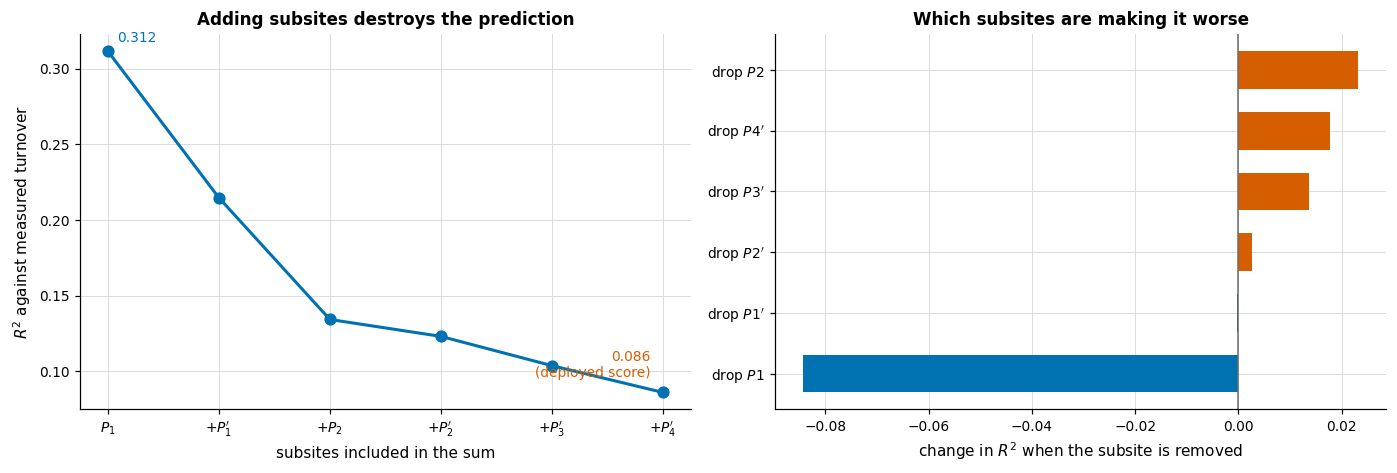

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

ax = axes[0]
ax.plot(range(len(cumulative)), cumulative["r2"], marker="o", markersize=7,
        color=common.CATEGORICAL_COLORS[0], linewidth=2.0)
ax.set_xticks(range(len(cumulative)))
ax.set_xticklabels(["$P_1$", "+$P_1'$", "+$P_2$", "+$P_2'$", "+$P_3'$", "+$P_4'$"])
ax.set_xlabel("subsites included in the sum")
ax.set_ylabel("$R^2$ against measured turnover")
ax.set_title("Adding subsites destroys the prediction")
ax.annotate(f"{cumulative['r2'].iloc[0]:.3f}", (0, cumulative["r2"].iloc[0]),
            textcoords="offset points", xytext=(6, 6), fontsize=9,
            color=common.CATEGORICAL_COLORS[0])
ax.annotate(f"{cumulative['r2'].iloc[-1]:.3f}\n(deployed score)",
            (len(cumulative) - 1, cumulative["r2"].iloc[-1]),
            textcoords="offset points", xytext=(-8, 10), fontsize=9, ha="right",
            color=common.CATEGORICAL_COLORS[1])

ax = axes[1]
order = leave_one_out.sort_values("change")
colours = [common.CATEGORICAL_COLORS[1] if value > 0 else common.CATEGORICAL_COLORS[0]
           for value in order["change"]]
ax.barh(range(len(order)), order["change"], color=colours, height=0.62)
ax.axvline(0.0, color=common.NEUTRAL, linewidth=1.0)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"drop ${name}$" for name in order["dropped"]])
ax.set_xlabel("change in $R^2$ when the subsite is removed")
ax.set_title("Which subsites are making it worse")

fig.tight_layout()
plt.show()

## 6. Benchmark under an identical validation protocol

Everything above compares scores that were fixed before this dataset was
touched. To place them against the paper's regression the comparison has to be
made fair in both directions, so a single protocol is used for every row:

* **one set** — all 43 314 substrate peptides, no row excluded for any model;
* **one split** — the same $K$-fold assignment, drawn once;
* **one metric** — out-of-sample $R^2$ and RMSE, pooled over held-out folds.

For the fixed scores the fold fits only a two-parameter linear calibration
$a + b\,s$, which puts nats and model units on the same footing without giving
them any shape they did not already have. For the model *forms* the fold refits
every coefficient, which is what makes those rows leak-free.

The published-model row is marked separately: its coefficients were fitted on
exactly these peptides, so it is an in-sample ceiling and not a fair competitor.
The cross-validated refit of the same form directly below it is the honest
number for that model class, and the two agreeing is the check that the
reconstruction of Dataset EV2 is correct.

In [13]:
rng = np.random.default_rng(SEED)
folds = rng.permutation(len(scored)) % N_FOLDS       # one split, reused by every row
p2_codes = np.array([residue_index[s[0]] for s in sequences])
p1_codes = np.array([residue_index[s[1]] for s in sequences])
prime_codes = np.array([residue_index[s[2]] for s in sequences])


def one_hot(codes: np.ndarray, n_levels: int = 20) -> np.ndarray:
    """Dummy coding of a categorical position with one level left out."""

    matrix = np.zeros((len(codes), n_levels))
    matrix[np.arange(len(codes)), codes] = 1.0
    return matrix[:, 1:]


def interaction(first: np.ndarray, second: np.ndarray) -> np.ndarray:
    """Dummy coding of the observed combinations of two positions."""

    matrix = np.zeros((len(first), 400))
    matrix[np.arange(len(first)), first * 20 + second] = 1.0
    return matrix[:, matrix.sum(axis=0) > 0][:, 1:]


DESIGNS = {
    "p1": lambda: one_hot(p1_codes),
    "additive": lambda: np.hstack([one_hot(p2_codes), one_hot(p1_codes), one_hot(prime_codes)]),
    "interaction": lambda: np.hstack([one_hot(p2_codes), one_hot(p1_codes), one_hot(prime_codes),
                                      interaction(p2_codes, p1_codes),
                                      interaction(p1_codes, prime_codes)]),
}


def cross_validated(design: np.ndarray) -> tuple[float, float]:
    """Pooled out-of-sample R^2 and RMSE over the shared folds.

    :param design: Predictor columns, ``(N, p)``; an intercept is added.
    :return: Out-of-sample R^2 and RMSE.
    """

    prediction = np.empty(len(turnover))
    for fold in range(N_FOLDS):
        test = folds == fold
        train = ~test
        ## REMARK: solved through the normal equations rather than by SVD, because
        ## the interaction design has 841 columns and lstsq is an order of
        ## magnitude slower on a matrix of this shape.
        A = np.hstack([np.ones((int(train.sum()), 1)), design[train]])
        gram = A.T @ A + 1e-8 * np.eye(A.shape[1])
        coefficients = np.linalg.solve(gram, A.T @ turnover[train])
        prediction[test] = np.hstack([np.ones((int(test.sum()), 1)), design[test]]) @ coefficients
    residual = turnover - prediction
    centred = turnover - turnover.mean()
    return (float(1.0 - residual @ residual / (centred @ centred)),
            float(np.sqrt(np.mean(residual ** 2))))


benchmark = []
r2, rmse = cross_validated(np.zeros((len(scored), 0)))
benchmark.append({"model": "null (intercept only)", "parameters": 0, "fitted_on_this_data": "no",
                  "spearman": 0.0, "pearson": 0.0, "cv_r2": r2, "cv_rmse": rmse})

for label, column, fitted in (
    ("peptide length (trivial baseline)", "length", "no"),
    ("MEROPS P1 column only", "merops_p1", "no"),
    ("MEROPS masked window score (deployed)", "merops_window", "no"),
    ("qPISA published model, Dataset EV2", "published_model", "yes — in-sample ceiling"),
):
    score = scored[column].to_numpy()
    r2, rmse = cross_validated(score.reshape(-1, 1))
    benchmark.append({"model": label, "parameters": 0, "fitted_on_this_data": fitted,
                      "spearman": float(spearmanr(score, turnover).statistic),
                      "pearson": float(pearsonr(score, turnover).statistic),
                      "cv_r2": r2, "cv_rmse": rmse})

for label, kind in (("refit: P1 only", "p1"),
                    ("refit: P2 + P1 + P1' (additive)", "additive"),
                    ("refit: P2 + P1 + P1' + P2:P1 + P1:P1'", "interaction")):
    design = DESIGNS[kind]()
    r2, rmse = cross_validated(design)
    A = np.hstack([np.ones((len(turnover), 1)), design])
    coefficients = np.linalg.solve(A.T @ A + 1e-8 * np.eye(A.shape[1]), A.T @ turnover)
    fitted_values = A @ coefficients
    residual = turnover - fitted_values
    centred = turnover - turnover.mean()
    in_sample = 1.0 - residual @ residual / (centred @ centred)
    benchmark.append({
        "model": label, "parameters": design.shape[1], "fitted_on_this_data": "cross-validated",
        "spearman": float(spearmanr(fitted_values, turnover).statistic),
        "pearson": float(pearsonr(fitted_values, turnover).statistic),
        "cv_r2": r2, "cv_rmse": rmse,
        "in_sample_adjusted_r2": float(1.0 - (1.0 - in_sample) * (len(turnover) - 1)
                                       / (len(turnover) - design.shape[1] - 1)),
    })

benchmark = pd.DataFrame(benchmark)
benchmark.insert(1, "peptides", len(scored))

print(f"Every row: n = {len(scored):,}, the same {N_FOLDS} folds, the same metric.")
print(benchmark.round(4).to_string(index=False))
print()
print("Reproduction of the paper's Fig 2A (their adjusted R2, our refit):")
for label, theirs in (("refit: P1 only", 60.7),
                      ("refit: P2 + P1 + P1' (additive)", 63.1),
                      ("refit: P2 + P1 + P1' + P2:P1 + P1:P1'", 72.7)):
    ours = float(benchmark.loc[benchmark["model"] == label, "in_sample_adjusted_r2"].iloc[0]) * 100
    print(f"  {label:<40s} paper {theirs:5.1f}%   ours {ours:5.1f}%   difference {ours - theirs:+.1f} pp")

Every row: n = 43,314, the same 5 folds, the same metric.
                                model  peptides  parameters     fitted_on_this_data  spearman  pearson   cv_r2  cv_rmse  in_sample_adjusted_r2
                null (intercept only)     43314           0                      no    0.0000   0.0000 -0.0000   1.0601                    NaN
    peptide length (trivial baseline)     43314           0                      no    0.0213   0.0035 -0.0000   1.0601                    NaN
                MEROPS P1 column only     43314           0                      no    0.2065   0.5582  0.3115   0.8796                    NaN
MEROPS masked window score (deployed)     43314           0                      no    0.1811   0.3280  0.1075   1.0015                    NaN
   qPISA published model, Dataset EV2     43314           0 yes — in-sample ceiling    0.4727   0.8508  0.7237   0.5572                    NaN
                       refit: P1 only     43314          19         cross-validated 

### Reading the figure

One bar per row of the table, on the only axis that is comparable across all of
them: the fraction of measured turnover predicted out of sample. The dotted line
is the paper's model class, which is the ceiling any sequence-local predictor can
be expected to reach on this data.

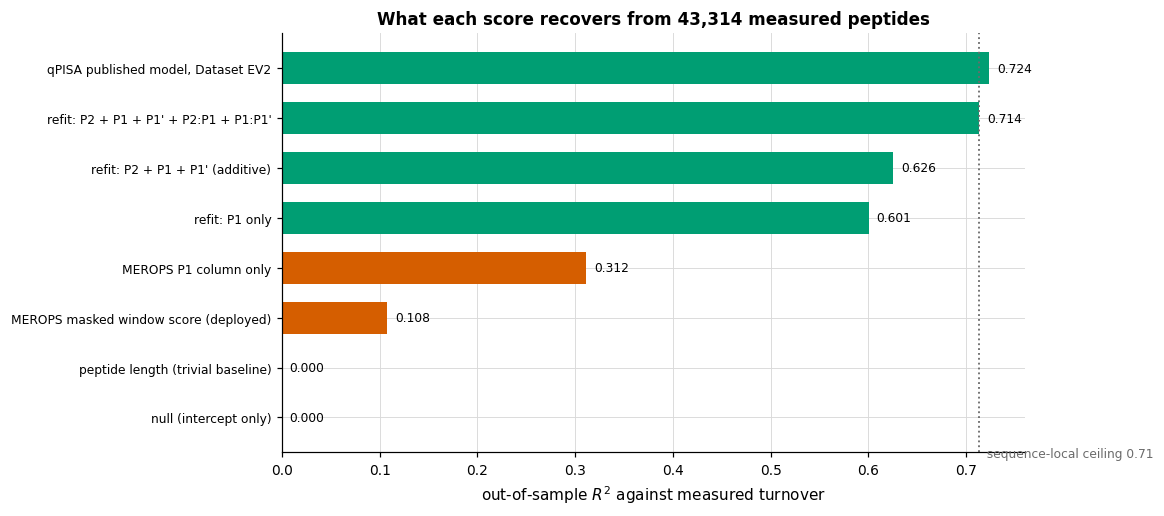

In [14]:
fig, ax = plt.subplots(figsize=(10.6, 4.8))
order = benchmark.sort_values("cv_r2")
colours = []
for label in order["model"]:
    if label.startswith("MEROPS"):
        colours.append(common.CATEGORICAL_COLORS[1])
    elif label.startswith("refit") or label.startswith("qPISA"):
        colours.append(common.CATEGORICAL_COLORS[2])
    else:
        colours.append(common.NEUTRAL)
ax.barh(range(len(order)), order["cv_r2"].clip(lower=0), color=colours, height=0.64)
ceiling = float(benchmark.loc[benchmark["model"].str.startswith("refit: P2 + P1 + P1' + P2"), "cv_r2"].iloc[0])
ax.axvline(ceiling, color=common.NEUTRAL, linestyle=":", linewidth=1.2)
ax.text(ceiling, -0.8, f"  sequence-local ceiling {ceiling:.2f}", fontsize=8, color=common.NEUTRAL)
for position, value in enumerate(order["cv_r2"]):
    ax.annotate(f"{max(value, 0):.3f}", (max(value, 0), position),
                textcoords="offset points", xytext=(5, 0), va="center", fontsize=8)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order["model"], fontsize=8)
ax.set_xlabel("out-of-sample $R^2$ against measured turnover")
ax.set_title(f"What each score recovers from {len(scored):,} measured peptides")
fig.tight_layout()
plt.show()

## 7. The per-subsite comparison, and what correcting for the library does to it

Sections 4 to 6 work peptide by peptide. The rest of the source audits — `0_05`
for PICS, and `0_07`, which places the two sources on one set of axes — work
matrix by matrix, comparing the subsite distributions of the source against
those of MEROPS. This section produces that comparison for qPISA, and it is the
only part of the notebook that reduces the measurement to a set of windows.

The reduction needs a threshold, because a window tally is a count of events and
a count needs a set of events to count. That set is defined here, once, and it
is also what `0_08` pools into the extended cleavage environment.

The comparison is then computed twice, which is the point.

* **Occurrence variant.** Tally those windows exactly as an occurrence-counting
  experiment such as PICS would report them. This is what a cleavage tally sees,
  and it is what `0_07` consumes, so that the two sources it compares are still
  reduced the same way.
* **Enrichment variant.** Divide each residue's frequency in the cleaved set by
  its frequency in the **whole substrate library**, then renormalise. The library
  is the correct background for this assay, and dividing by it removes the
  composition of the HeLa digest from the estimate.

The difference between the two is the size of the confound §4.1 exposed at
$P_1$, now measured at every subsite.

In [15]:
## The one threshold in the notebook, applied only to define countable events.
evidence = scored[scored["turnover"] > EVIDENCE_TURNOVER_THRESHOLD]


def dpp4_window(sequence: str) -> str:
    """Return the P4..P4' window of the DPP4 event on one peptide.

    :param sequence: Peptide sequence, N terminus first.
    :return: Eight-character window with P4 and P3 written as gaps.
    """

    return "--" + sequence[:6]


cleaved_windows = [dpp4_window(s) for s in evidence["sequence"]]
library_windows = [dpp4_window(s) for s in scored["sequence"]]
windows_frame = pd.DataFrame({
    "merops_code": DPP4_MEROPS_CODE,
    "window": cleaved_windows,
    "stratum": pd.qcut(evidence["turnover"], 5,
                       labels=[f"turnover Q{i + 1}" for i in range(5)]).astype(str).to_numpy(),
})

cleaved_counts = specificity_counts_from_windows(cleaved_windows)         # (8, 20)
library_counts = specificity_counts_from_windows(library_windows)         # (8, 20)

## Occurrence: the cleaved tally on its own, as a cleavage-counting assay reports it
occurrence_matrix = log_probability_matrix(cleaved_counts)                # (8, 20)

## Enrichment: the same tally divided by the library that produced it
SMOOTHING = 0.5
cleaved_frequency = ((cleaved_counts + SMOOTHING)
                     / (cleaved_counts + SMOOTHING).sum(axis=1, keepdims=True))   # (8, 20)
library_frequency = ((library_counts + SMOOTHING)
                     / (library_counts + SMOOTHING).sum(axis=1, keepdims=True))   # (8, 20)
ratio = cleaved_frequency / library_frequency                             # (8, 20)
enrichment_matrix = np.log(ratio / ratio.sum(axis=1, keepdims=True))      # (8, 20)

## DPP4 cuts two residues from the N terminus, so P4 and P3 never exist.
OBSERVED_SUBSITES = (False, False, True, True, True, True, True, True)
agreement = pd.DataFrame(
    compare_specificity_matrices(merops_matrix, occurrence_matrix, OBSERVED_SUBSITES)
).assign(merops_code=DPP4_MEROPS_CODE, source_windows=len(cleaved_windows))
agreement = agreement[["merops_code", "source_windows", "subsite", "observed", "spearman",
                       "jensen_shannon_bits", "top_residue_reference",
                       "top_residue_candidate", "top_residue_agrees"]]
agreement_corrected = pd.DataFrame(
    compare_specificity_matrices(merops_matrix, enrichment_matrix, OBSERVED_SUBSITES)
).assign(merops_code=DPP4_MEROPS_CODE, source_windows=len(cleaved_windows))

merops_cleavages = int(dpp4_counts.sum(axis=1).max())
intersection = pd.DataFrame([{
    "merops_code": DPP4_MEROPS_CODE,
    "source_windows": len(cleaved_windows),
    "source_distinct_windows": len(set(cleaved_windows)),
    "merops_cleavages": merops_cleavages,
    "in_merops": True,
    "evidence_ratio": len(set(cleaved_windows)) / merops_cleavages,
}])

comparison = agreement.merge(
    agreement_corrected[["subsite", "spearman", "jensen_shannon_bits", "top_residue_candidate"]],
    on="subsite", suffixes=("_occurrence", "_enrichment"),
)
observed_only = comparison[comparison["observed"]]

print(f"cleavage events tallied: {len(cleaved_windows):,} windows "
      f"({len(set(cleaved_windows)):,} distinct) at turnover > {EVIDENCE_TURNOVER_THRESHOLD} log2,")
print(f"against the full substrate library of {len(library_windows):,} peptides used as background.")
print()
print(observed_only[["subsite", "spearman_occurrence", "spearman_enrichment",
                     "jensen_shannon_bits_occurrence", "jensen_shannon_bits_enrichment",
                     "top_residue_reference", "top_residue_candidate_occurrence",
                     "top_residue_candidate_enrichment"]].round(3).to_string(index=False))
print()
print(f"median rank agreement, occurrence variant  {observed_only['spearman_occurrence'].median():+.3f}")
print(f"median rank agreement, enrichment variant  {observed_only['spearman_enrichment'].median():+.3f}")
print()
print("At P1 the correction is the whole argument of section 4.1:")
p1_row = observed_only[observed_only["subsite"] == "P1"].iloc[0]
print(f"  MEROPS says the top residue is      {p1_row['top_residue_reference']}")
print(f"  the raw window tally says           {p1_row['top_residue_candidate_occurrence']}")
print(f"  corrected for the library it says   {p1_row['top_residue_candidate_enrichment']}")

cleavage events tallied: 4,926 windows (4,781 distinct) at turnover > 1.0 log2,
against the full substrate library of 43,314 peptides used as background.

subsite  spearman_occurrence  spearman_enrichment  jensen_shannon_bits_occurrence  jensen_shannon_bits_enrichment top_residue_reference top_residue_candidate_occurrence top_residue_candidate_enrichment
     P2                0.301                0.307                           0.164                           0.128                     G                                L                                K
     P1                0.365                0.420                           0.250                           0.172                     P                                A                                P
    P1p                0.545                0.259                           0.095                           0.119                     L                                L                                W
    P2p                0.431         

### Reading the figure

Two bars per subsite: the rank agreement with MEROPS computed from the raw
window tally, and the same statistic computed after dividing by the library the
peptides came from. Where the pair differs, the raw number was reporting the
composition of the HeLa digest as if it were a property of the enzyme.

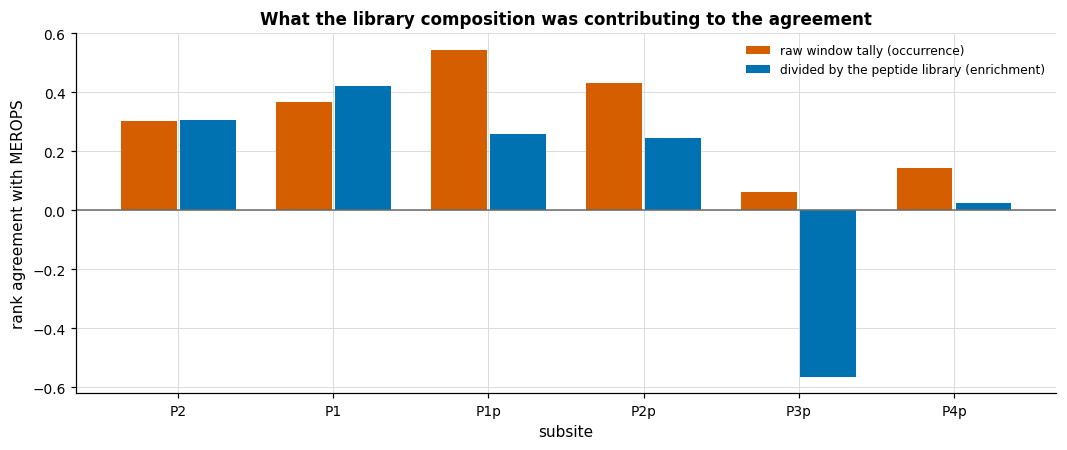

In [16]:
fig, ax = plt.subplots(figsize=(9.8, 4.2))
subsite_labels = observed_only["subsite"].to_list()
positions = np.arange(len(subsite_labels))
ax.bar(positions - 0.19, observed_only["spearman_occurrence"], width=0.36,
       color=common.CATEGORICAL_COLORS[1], label="raw window tally (occurrence)")
ax.bar(positions + 0.19, observed_only["spearman_enrichment"], width=0.36,
       color=common.CATEGORICAL_COLORS[0], label="divided by the peptide library (enrichment)")
ax.axhline(0.0, color=common.NEUTRAL, linewidth=1.0)
ax.set_xticks(positions)
ax.set_xticklabels(subsite_labels)
ax.set_xlabel("subsite")
ax.set_ylabel("rank agreement with MEROPS")
ax.set_title("What the library composition was contributing to the agreement")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [17]:
common.save_result(windows_frame, "0_06_windows.csv")
common.save_result(funnel, "0_06_funnel.csv")
common.save_result(discrimination, "0_06_discrimination.csv")
common.save_result(p1_table, "0_06_p1_effects.csv")
common.save_result(inhibition, "0_06_p1prime_inhibition.csv")
common.save_result(single, "0_06_subsite_single.csv")
common.save_result(cumulative, "0_06_subsite_cumulative.csv")
common.save_result(leave_one_out, "0_06_subsite_leave_one_out.csv")
common.save_result(benchmark, "0_06_benchmark.csv")
common.save_result(agreement, "0_06_profile_agreement.csv")
common.save_result(agreement_corrected, "0_06_profile_agreement_corrected.csv")
common.save_result(intersection, "0_06_intersection.csv")
common.save_result(
    scored.assign(turnover_decile=pd.qcut(scored["turnover"], 10, labels=False, duplicates="drop")),
    "0_06_scored_peptides.csv",
)

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_06_scored_peptides.csv')

## Findings and decisions

**The reproduction succeeds, so the comparison is trustworthy.** Refitting the
paper's three model forms on the deposited measurements reproduces their Fig 2A
to within 0.7 percentage points on all three ($P_1$ only, additive, and with the
two interaction terms). The reconstruction of Dataset EV2 orders the GLP-1
engineering variants exactly as the paper's in vitro assay did. Anything the
rest of this notebook says about MEROPS is therefore said against a correctly
reconstructed benchmark.

**MEROPS recovers the direction at $P_1$ and nothing beyond the first residue.**
The measured ranking at $P_1$ is Pro > Ala > Ser > Thr > Gly and the paper's
fitted term reproduces it exactly. MEROPS puts Pro first, which is right, and
then Cys and Trp ahead of Ala, which is not: those two residues have one and
zero recorded cleavages respectively, and they rank high only because the
log-odds divides by a small proteome background frequency. The magnitude is
wrong in the direction the paper predicted — Ala reaches 79% of Pro in the
measurement and 85% in their model, against 24% in MEROPS.

**MEROPS cannot express inhibition, and this is structural rather than a matter
of evidence.** Proline at $P_1'$ removes 3.37 log2 units of turnover in the
measurement, cancelling cleavage outright for peptides that otherwise carry the
best possible $P_1$; the paper's fitted term is −3.06. MEROPS places Pro at the
floor of its $P_1'$ column, but that floor is shared with every other residue it
never observed, and the entire column spans 2.85 nats — narrower than the effect
it would have to represent. Summed additively, MEROPS still scores a Pro-Pro
peptide as favourable. A tally of observed cleavages has no channel for a
residue that prevents cleavage, and no amount of additional literature would
give it one.

**The deployed window score explains 11% of measured turnover, and its own $P_1$
column explains 31%.** Out of sample, on 43 314 peptides under one protocol:
null 0.000, peptide length 0.000, masked window score 0.107, MEROPS $P_1$ column
alone 0.312, cross-validated refit of the paper's form 0.714, published model
0.724. The window score is far outside its permutation null — it carries real
information — but it recovers roughly a seventh of what the same peptides'
sequences support.

**Adding subsites to the score makes it worse, monotonically.** $P_1$ alone
reaches $R^2 = 0.312$; adding $P_1'$ drops it to 0.215, adding $P_2$ to 0.134,
and the full six-subsite window to 0.086. Leave-one-out confirms the direction:
deleting $P_2$, $P_3'$ or $P_4'$ each *improves* the score, and deleting $P_1$
leaves 0.002, that is nothing. The non-$P_1$ columns of this matrix are built
from 20 cleavages spread over 20 residues; they are not weak evidence being
diluted, they are noise entering the sum with the same weight as the one column
that works.

**The apparent MEROPS/qPISA disagreement at $P_1$ was the reduction, not the
database.** Section 7 tallies the cleaved windows the way an occurrence-counting
assay would and gets Ala as the top residue at $P_1$, contradicting MEROPS, which
says Pro. Dividing the same tally by the peptide library it came from returns Pro
to first place — in agreement with MEROPS and with the measurement — and lifts the
rank agreement at $P_1$ from 0.365 to 0.420. Ala is simply 1.9x more common than
Pro at that position in a HeLa tryptic digest. The correction does not rescue the
rest of the matrix: the median rank agreement across subsites *falls* from 0.333 to
0.252, because $P_3'$ moves from +0.061 to **-0.565** once composition is removed,
which is the same anti-informative column section 5 found by a different route.

**The window export to `0_08` is the uncorrected variant, deliberately and with a
cost.** `0_08` pools independent windows into MEROPS counts, and a count is what it
needs; an enrichment is not a count. So `0_06_windows.csv` carries the raw tally,
and the extended cleavage environment inherits the HeLa digest's composition at
every subsite it gains from qPISA. This is recorded as a defect rather than fixed,
because fixing it means changing what `0_08` pools, which is a decision about the
extended environment and not about this source.

**Decisions.**

1. The DPP4 window score is not used at full width anywhere downstream without
   this result being cited beside it. For this protease the $P_1$ restriction is
   strictly better, and the general question — whether an evidence-weighted or
   subsite-restricted score beats the flat sum across the panel — is now a
   measured question rather than a speculative one.
2. qPISA is not merged into the matrices. It measures one protease, and its
   value here is as an external standard, which is destroyed by absorbing it.
3. The inability to represent inhibition is recorded as a property of the MEROPS
   representation, not of this dataset. It applies to every protease in the
   panel and cannot be repaired by more evidence.
4. The 4 h endpoint at 21 °C measures extent of turnover, not a rate, so this
   notebook constrains the *shape* of a preference and still supplies no
   absolute scale. Nothing here changes the `use_for_shape` classification in
   `0_09`.